In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# Set seed for reproducibility
np.random.seed(42)

# Generate class +1
class1 = np.random.randn(50, 2) + np.array([2, 2])

# Generate class -1
class2 = np.random.randn(50, 2) + np.array([-2, -2])

# Labels
y1 = np.ones(50)
y2 = -np.ones(50)

# Combine data
X = np.vstack((class1, class2))
y = np.hstack((y1, y2))

# Convert to DataFrame
df = pd.DataFrame(X, columns=['feature1', 'feature2'])
df['label'] = y

df.sample(5)

,feature1,feature2,label
93,-1.526762,-2.072829,-1.0
28,1.160782,1.690788,1.0
55,-3.918771,-2.026514,-1.0
30,1.520826,1.814341,1.0
80,-2.974682,-1.212915,-1.0


In [5]:
### Visualize the data.

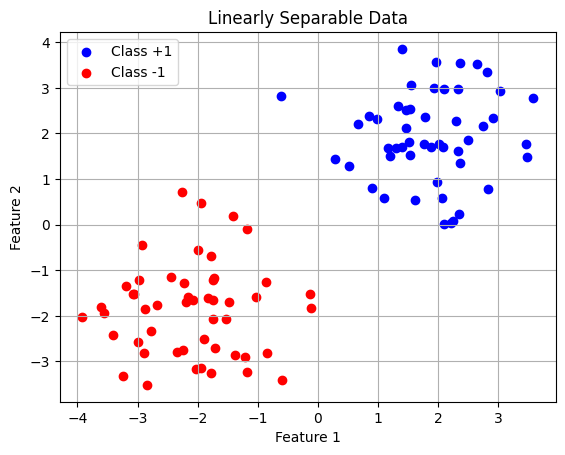

In [15]:
plt.scatter(class1[:, 0], class1[:, 1], color='blue', label='Class +1')
plt.scatter(class2[:, 0], class2[:, 1], color='red', label='Class -1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linearly Separable Data")
plt.legend()
plt.grid()

plt.show()

In [8]:
### Apply the Hard Margin SVM or Maximal margin classifier. 

In [9]:
from sklearn.svm import SVC

model = SVC(kernel='linear', C=1e10)  # very large C ≈ hard margin
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

In [12]:
### Visuals of the model line.

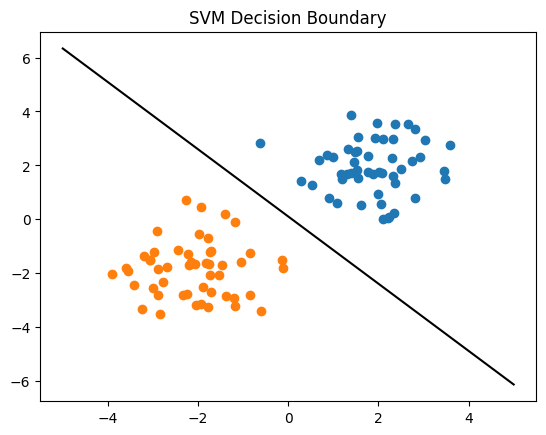

In [10]:
w = model.coef_[0]
b = model.intercept_[0]

# Create line
x_points = np.linspace(-5, 5, 100)
y_points = -(w[0] * x_points + b) / w[1]

plt.scatter(class1[:, 0], class1[:, 1])
plt.scatter(class2[:, 0], class2[:, 1])
plt.plot(x_points, y_points, color='black')

plt.title("SVM Decision Boundary")
plt.show()

In [13]:
### Visuals of the margin lines

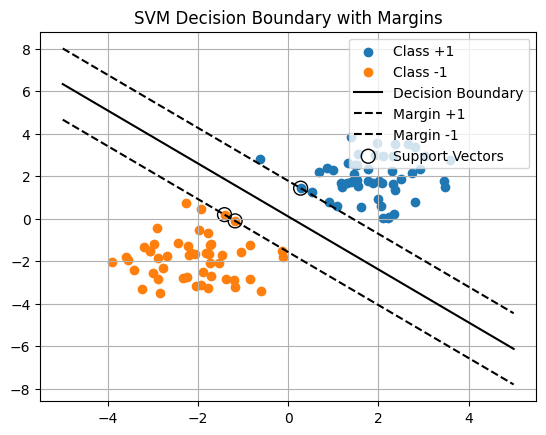

In [11]:

# Extract parameters
w = model.coef_[0]
b = model.intercept_[0]

# Create x values
x_points = np.linspace(-5, 5, 100)

# Decision boundary
y_points = -(w[0] * x_points + b) / w[1]

# ---- Margin lines ----
y_margin_pos = -(w[0] * x_points + b - 1) / w[1]   # w.x + b = +1
y_margin_neg = -(w[0] * x_points + b + 1) / w[1]   # w.x + b = -1

# ---- Plot ----
plt.scatter(class1[:, 0], class1[:, 1], label='Class +1')
plt.scatter(class2[:, 0], class2[:, 1], label='Class -1')

# Decision boundary
plt.plot(x_points, y_points, color='black', label='Decision Boundary')

# Margins
plt.plot(x_points, y_margin_pos, 'k--', label='Margin +1')
plt.plot(x_points, y_margin_neg, 'k--', label='Margin -1')

# Support vectors (optional but recommended)
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='black',
            label='Support Vectors')

plt.title("SVM Decision Boundary with Margins")
plt.legend()
plt.grid()
plt.show()